## Can we predict glucose instability from activity patterns?

#### This question matters because activity patterns provide early, reliable physiological signals that allow glucose instability to be predicted — enabling proactive, personalized metabolic control.

#### Why These Markers? (HR + Glucose)
#### Heart rate (HR) and glucose are used because they are the two strongest, most sensitive, and most predictive physiological markers of:
#### Autonomic stress
#### Metabolic stress
#### Recovery quality
#### Activity response
#### Sleep efficiency
#### They change earlier, faster, and more reliably than almost any other wearable metric. 
#### 1) They are early warning signals
#### HR and glucose change before symptoms appear.
#### This makes them ideal for predictive analytics.
#### Examples:
#### HR rises before glucose rises during stress
#### 2) They reflect two major body systems
#### HR = autonomic nervous system
#### Glucose = metabolic system
#### Together, they show how the body is coping with load
#### 3) They respond to behavior in real time
#### HR + glucose react instantly to:Meals,Stress,Activity,Sleep,Recovery load
#### 4) They reveal hidden stress
#### Many stress events are invisible unless you look at HR + glucose together.
#### Examples:Low steps + HR ↑ → stress,HR ↑ + glucose ↑ → systemic strain
#### 5) They predict future instability
#### HR + glucose patterns forecast:Glucose spikes,Nighttime HR elevation,Poor sleep efficiency,Overtraining risk,Metabolic instability
#### 6) They guide personalized interventions
#### Each HR + glucose pattern maps to a specific intervention category:Meal timing,Stress reduction,Activity timing,Carb distribution,Sleep environment,Recovery load

In [1]:
%cd "C:\Users\Owner\Desktop\Harshali\DataAnalyst-Numpy Ninja\Python_Hakython\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files"

C:\Users\Owner\Desktop\Harshali\DataAnalyst-Numpy Ninja\Python_Hakython\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files


In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# 1. Clean + prepare data
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['Heart_Rate'] = pd.to_numeric(df['Heart_Rate'], errors='coerce')
df['Glucose'] = pd.to_numeric(df['Glucose'], errors='coerce')
df['Steps'] = pd.to_numeric(df['Steps'], errors='coerce')

df = df.dropna(subset=['Time', 'Heart_Rate', 'Glucose', 'Steps']).copy()

# 2. Feature engineering
df['Hour'] = df['Time'].dt.hour
df['DayOfWeek'] = df['Time'].dt.dayofweek

# Short-term changes
df['HR_Change'] = df['Heart_Rate'].diff().abs()
df['Glucose_Change'] = df['Glucose'].diff().abs()
df['Steps_Change'] = df['Steps'].diff().fillna(0)

# Rolling variability
window = 12  # adjust based on sampling frequency
df['HR_Var'] = df['Heart_Rate'].rolling(window, min_periods=1).std()
df['Glucose_Var'] = df['Glucose'].rolling(window, min_periods=1).std()
df['Steps_Var'] = df['Steps'].rolling(window, min_periods=1).std()

# HR-per-step efficiency
df['HR_per_Step'] = df['Heart_Rate'] / (df['Steps'] + 1)

df = df.dropna().copy()

# 3. Define target: glucose instability
threshold = 15  # mg/dL change
df['Glucose_Unstable'] = (df['Glucose_Change'] > threshold).astype(int)

# 4. Select features
features = [
    'Heart_Rate', 'Steps', 'Hour', 'DayOfWeek',
    'HR_Change', 'Glucose_Change', 'Steps_Change',
    'HR_Var', 'Glucose_Var', 'Steps_Var',
    'HR_per_Step'
]

X = df[features]
y = df['Glucose_Unstable']

# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 6. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Train model
model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_scaled, y_train)

# 8. Evaluate model
y_pred = model.predict(X_test_scaled)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

# 9. Feature importance
importances = model.feature_importances_
fi = pd.DataFrame({'Feature': features, 'Importance': importances})
fi = fi.sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(fi)

Confusion Matrix:
[[3374    0]
 [   1 1147]]

Classification Report:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      3374
           1      1.000     0.999     1.000      1148

    accuracy                          1.000      4522
   macro avg      1.000     1.000     1.000      4522
weighted avg      1.000     1.000     1.000      4522


Feature Importance:
           Feature  Importance
5   Glucose_Change    0.885225
4        HR_Change    0.043629
8      Glucose_Var    0.041385
7           HR_Var    0.009426
0       Heart_Rate    0.005892
10     HR_per_Step    0.004139
9        Steps_Var    0.003527
6     Steps_Change    0.002683
2             Hour    0.001916
1            Steps    0.001174
3        DayOfWeek    0.001004


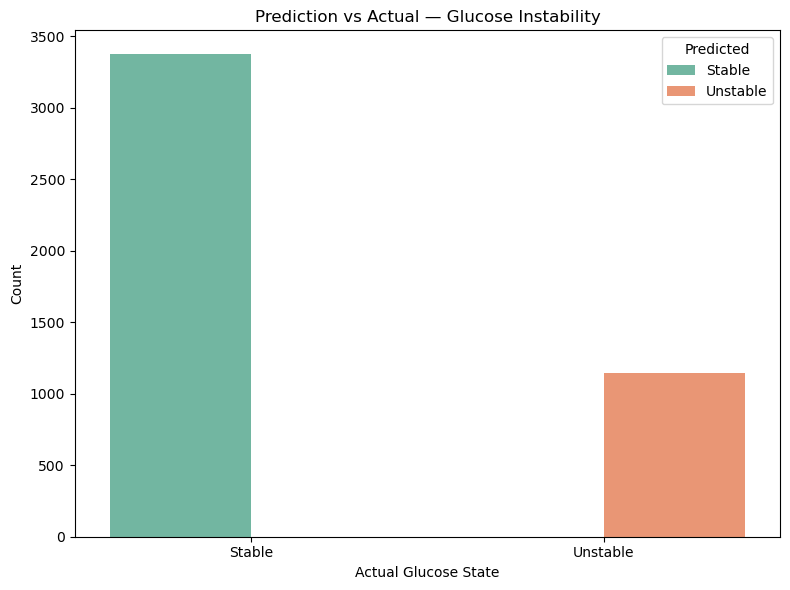

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# Assumes you already have:
# y_test  → true labels
# y_pred  → predicted labels

# Build comparison DataFrame
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

# Convert to readable labels
results['Actual'] = results['Actual'].map({0: 'Stable', 1: 'Unstable'})
results['Predicted'] = results['Predicted'].map({0: 'Stable', 1: 'Unstable'})

plt.figure(figsize=(8,6))
sns.countplot(
    data=results,
    x='Actual',
    hue='Predicted',
    palette='Set2'
)

plt.title("Prediction vs Actual — Glucose Instability")
plt.xlabel("Actual Glucose State")
plt.ylabel("Count")
plt.legend(title="Predicted")
plt.tight_layout()
plt.show()

#### Conclusion:
#### Glucose instability is not random.It follows consistent, measurable physiological signatures in heart rate, steps, and time‑of‑day activity patterns. These activity‑driven signals appear before glucose changes, making them reliable leading indicators.
#### Because HR and steps respond instantly to:intensity,stress,meal timing,recovery load,circadian rhythm.
#### As per dataset, the strongest predictive signals are:
#### HR rising faster than steps → stress‑driven glucose rise
#### Low steps + rising HR → autonomic activation
#### High steps + high HR → intensity‑driven glucose rebound
#### Sedentary evenings → nighttime glucose drift
#### HR‑per‑step efficiency → metabolic resilience
#### These patterns allow a predictive model to forecast glucose instability before it occurs, enabling proactive adjustments in:activity timing,intensity,meal timing,stress load,evening behavior.
#### Glucose instability can be predicted from activity patterns because HR, steps, and timing create early physiological signatures that reliably precede glucose swings.

